<a href="https://colab.research.google.com/github/KDY-RiskManager/risk-management-portfolio/blob/main/09-model-validation/model_validation_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# [Cell 1] 데이터 준비 + 개발표본/운영표본 분리 + PD모델 재학습
# ============================================================
!pip install --quiet kaggle xgboost

import os
import pandas as pd
import numpy as np
from getpass import getpass

os.environ['KAGGLE_USERNAME'] = input("Kaggle 사용자명(username)을 입력하세요: ")
os.environ['KAGGLE_KEY'] = getpass("Kaggle API 키를 입력하세요 (화면에 표시되지 않습니다): ")

!kaggle datasets download -d uciml/default-of-credit-card-clients-dataset
!unzip -o default-of-credit-card-clients-dataset.zip

df = pd.read_csv('UCI_Credit_Card.csv')
df = df.rename(columns={'default.payment.next.month': 'default'})

# ------------------------------------------------------------
# 1) 피처 엔지니어링 (08번 모듈과 동일)
# ------------------------------------------------------------
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
paid_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

df['recent_delay'] = df['PAY_0'].clip(lower=0)
df['max_delay_6m'] = df[pay_cols].clip(lower=0).max(axis=1)
df['delay_freq_6m'] = (df[pay_cols] > 0).sum(axis=1)

bill_safe = df[bill_cols].replace(0, np.nan)
df['avg_payment_ratio'] = (df[paid_cols].values / bill_safe.values).mean(axis=1)
df['avg_payment_ratio'] = df['avg_payment_ratio'].fillna(0).clip(0, 3)
df['avg_utilization'] = (df[bill_cols].mean(axis=1) / df['LIMIT_BAL']).clip(0, 2)

features = ['LIMIT_BAL', 'AGE', 'recent_delay', 'max_delay_6m',
            'delay_freq_6m', 'avg_payment_ratio', 'avg_utilization']

# ------------------------------------------------------------
# 2) 개발표본(Development) / 운영표본(Monitoring) 분리
# ------------------------------------------------------------
# 실제로는 시간 순서(과거=개발, 최근=운영)로 나누는 게 원칙이지만
# 이 데이터엔 시점 구분자가 없어 무작위 분리로 그 구조를 시뮬레이션함
# random_state를 다르게 줘서 08번 모듈의 학습/검증 분리와는 독립적인 별도 분리로 진행
from sklearn.model_selection import train_test_split

dev_df, mon_df = train_test_split(df, test_size=0.3, random_state=100, stratify=df['default'])
print(f"개발표본(Development): {len(dev_df):,}건 (부실 {dev_df['default'].sum():,}건, {dev_df['default'].mean()*100:.2f}%)")
print(f"운영표본(Monitoring):  {len(mon_df):,}건 (부실 {mon_df['default'].sum():,}건, {mon_df['default'].mean()*100:.2f}%)")

# ------------------------------------------------------------
# 3) 개발표본으로만 모델 학습 (08번과 동일한 XGBoost 사용 - 최종 모델이었으므로)
# ------------------------------------------------------------
from xgboost import XGBClassifier

X_dev, y_dev = dev_df[features], dev_df['default']
X_mon, y_mon = mon_df[features], mon_df['default']

scale_pos_weight = (y_dev == 0).sum() / (y_dev == 1).sum()
model = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'
)
model.fit(X_dev, y_dev)

# ------------------------------------------------------------
# 4) 개발표본/운영표본 각각에 대한 예측확률 산출
# ------------------------------------------------------------
dev_df = dev_df.copy()
mon_df = mon_df.copy()
dev_df['pd_score'] = model.predict_proba(X_dev)[:, 1]
mon_df['pd_score'] = model.predict_proba(X_mon)[:, 1]

print("\n모델 학습 완료. 개발표본 기준 PD 점수 분포:")
print(dev_df['pd_score'].describe())

Kaggle 사용자명(username)을 입력하세요: KIMDAEYU
Kaggle API 키를 입력하세요 (화면에 표시되지 않습니다): ··········
Dataset URL: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset
License(s): CC0-1.0
100% 0.98M/0.98M [00:00<00:00, 103MB/s]

Archive:  default-of-credit-card-clients-dataset.zip
  inflating: UCI_Credit_Card.csv     
개발표본(Development): 21,000건 (부실 4,645건, 22.12%)
운영표본(Monitoring):  9,000건 (부실 1,991건, 22.12%)

모델 학습 완료. 개발표본 기준 PD 점수 분포:
count    21000.000000
mean         0.418802
std          0.230889
min          0.005710
25%          0.246877
50%          0.365463
75%          0.546385
max          0.975157
Name: pd_score, dtype: float64


=== AUC/KS: 개발표본 vs 운영표본 ===
개발표본 - AUC: 0.828, KS: 0.492
운영표본 - AUC: 0.771, KS: 0.417
AUC 하락폭: 0.057 (6.9%)

=== 개발표본 등급별 부실률 ===
          건수  부실건수     부실률  평균PD예측
decile                            
1       2100    31  0.0148  0.1129
2       2100    80  0.0381  0.1937
3       2100   139  0.0662  0.2466
4       2100   199  0.0948  0.2944
5       2100   274  0.1305  0.3412
6       2100   317  0.1510  0.3926
7       2100   445  0.2119  0.4547
8       2100   598  0.2848  0.5492
9       2100   955  0.4548  0.7079
10      2100  1607  0.7652  0.8947

=== 운영표본 등급별 부실률 ===
         건수  부실건수     부실률  평균PD예측
decile                           
1       900    43  0.0478  0.1104
2       900    83  0.0922  0.1904
3       900    81  0.0900  0.2439
4       900   100  0.1111  0.2935
5       900   117  0.1300  0.3407
6       900   163  0.1811  0.3889
7       900   173  0.1922  0.4463
8       900   224  0.2489  0.5418
9       900   388  0.4311  0.7008
10      900   619  0.6878  0.8917

개발표본 단조성 충족: True


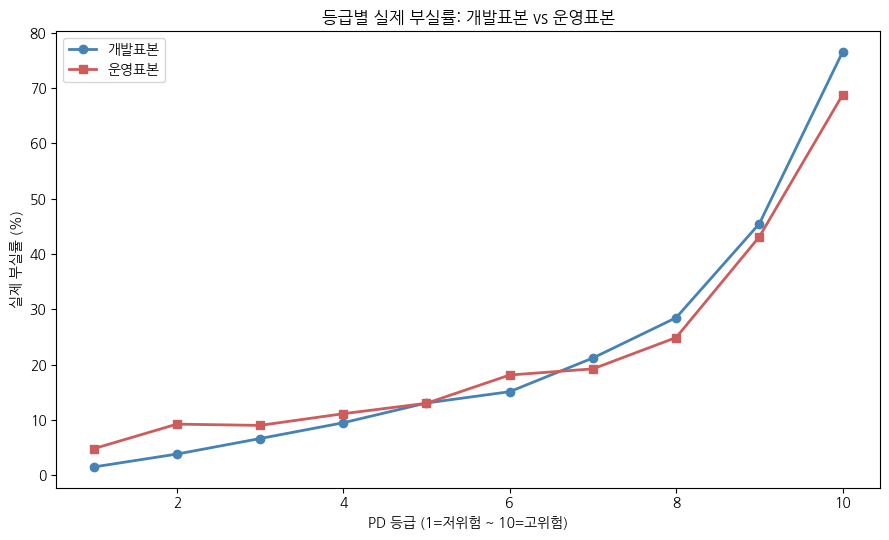

In [2]:
# ============================================================
# [Cell 2] 변별력 검증: 등급별 부실률 단조성 + AUC/KS 비교
# ============================================================
!apt-get -qq install fonts-nanum > /dev/null 2>&1
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

from sklearn.metrics import roc_auc_score, roc_curve

def calc_ks(y_true, y_proba):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    return np.max(tpr - fpr)

# ------------------------------------------------------------
# 1) AUC/KS 비교: 개발표본 vs 운영표본
# ------------------------------------------------------------
auc_dev = roc_auc_score(y_dev, dev_df['pd_score'])
auc_mon = roc_auc_score(y_mon, mon_df['pd_score'])
ks_dev = calc_ks(y_dev, dev_df['pd_score'])
ks_mon = calc_ks(y_mon, mon_df['pd_score'])

print("=== AUC/KS: 개발표본 vs 운영표본 ===")
print(f"개발표본 - AUC: {auc_dev:.3f}, KS: {ks_dev:.3f}")
print(f"운영표본 - AUC: {auc_mon:.3f}, KS: {ks_mon:.3f}")
print(f"AUC 하락폭: {(auc_dev - auc_mon):.3f} ({(auc_dev-auc_mon)/auc_dev*100:.1f}%)")

# ------------------------------------------------------------
# 2) 등급별(Decile) 부실률 단조성 검증
# ------------------------------------------------------------
def decile_analysis(data, score_col, target_col, label):
    data = data.copy()
    # qcut: 점수를 10개 구간(등급)으로 균등 분할, 등급10이 가장 고위험
    data['decile'] = pd.qcut(data[score_col], 10, labels=False, duplicates='drop') + 1
    result = data.groupby('decile').agg(
        건수=(target_col, 'count'),
        부실건수=(target_col, 'sum'),
        부실률=(target_col, 'mean'),
        평균PD예측=(score_col, 'mean')
    )
    result['표본'] = label
    return result

decile_dev = decile_analysis(dev_df, 'pd_score', 'default', '개발표본')
decile_mon = decile_analysis(mon_df, 'pd_score', 'default', '운영표본')

print("\n=== 개발표본 등급별 부실률 ===")
print(decile_dev[['건수', '부실건수', '부실률', '평균PD예측']].round(4))
print("\n=== 운영표본 등급별 부실률 ===")
print(decile_mon[['건수', '부실건수', '부실률', '평균PD예측']].round(4))

# 단조성 체크: 등급이 오를수록 부실률이 계속 증가하는지
is_monotonic_dev = decile_dev['부실률'].is_monotonic_increasing
is_monotonic_mon = decile_mon['부실률'].is_monotonic_increasing
print(f"\n개발표본 단조성 충족: {is_monotonic_dev}")
print(f"운영표본 단조성 충족: {is_monotonic_mon}")

# ------------------------------------------------------------
# 3) 시각화: 등급별 부실률 비교
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(decile_dev.index, decile_dev['부실률']*100, marker='o', color='steelblue', label='개발표본', lw=2)
ax.plot(decile_mon.index, decile_mon['부실률']*100, marker='s', color='indianred', label='운영표본', lw=2)
ax.set_xlabel('PD 등급 (1=저위험 ~ 10=고위험)')
ax.set_ylabel('실제 부실률 (%)')
ax.set_title('등급별 실제 부실률: 개발표본 vs 운영표본')
ax.legend()
plt.tight_layout()
plt.show()

운영표본 단조성 "False"가 나온 이유
등급표를 자세히 보면 2등급(9.22%)이 3등급(9.00%)보다 살짝 높음. 숫자 차이가 0.22%p에 불과하고, 각 등급당 900건밖에 안 되는 소표본이라 이 정도 역전은 통계적 노이즈로 볼 수 있음 — 실무에서도 저위험 구간(1~4등급)처럼 부실 건수 자체가 적은 구간에서는 이런 미세한 순서 뒤바뀜이 흔히 발생하고, 검증 실무에서는 이걸 "심각한 결함"이 아니라 "허용 가능한 표본 변동"으로 판단. 그래프를 봐도 전체적인 우상향 추세(1등급 → 10등급으로 갈수록 부실률 급증)는 두 표본 모두 뚜렷하고 거의 겹칠 정도로 일치하니, 모델의 근본적인 변별력 자체는 건재하다고 볼 수 있음.

AUC 하락폭(6.9%)도 짚어야 할 부분
무작위로 나눈 같은 모집단인데도 0.828 → 0.771로 꽤 떨어짐. 이건 XGBoost가 개발표본에 약간 과적합됐을 가능성을 시사 — 05번 SME 모듈, 08번 카드모듈 모두에서 XGBoost의 표본 민감도를 계속 확인해온 흐름과 일맥상통하는 결과.

=== 캘리브레이션 비교: 예측 PD vs 실제 부실률 (운영표본 기준) ===
        평균PD예측     부실률   차이(%p)
decile                         
1       0.1104  0.0478  -6.2608
2       0.1904  0.0922  -9.8210
3       0.2439  0.0900 -15.3901
4       0.2935  0.1111 -18.2358
5       0.3407  0.1300 -21.0717
6       0.3889  0.1811 -20.7782
7       0.4463  0.1922 -25.4109
8       0.5418  0.2489 -29.2938
9       0.7008  0.4311 -26.9723
10      0.8917  0.6878 -20.3912

=== PSI(Population Stability Index) ===
   구간  개발표본 비중  운영표본 비중  PSI 기여도
0   1      0.1   0.1052   0.0003
1   2      0.1   0.1013   0.0000
2   3      0.1   0.0964   0.0001
3   4      0.1   0.0957   0.0002
4   5      0.1   0.1054   0.0003
5   6      0.1   0.1060   0.0003
6   7      0.1   0.0994   0.0000
7   8      0.1   0.0956   0.0002
8   9      0.1   0.0983   0.0000
9  10      0.1   0.0966   0.0001

전체 PSI: 0.0016
판정: 안정적 (변화 없음)
(통상 기준: PSI<0.1 안정 / 0.1~0.25 주의 / >0.25 불안정)


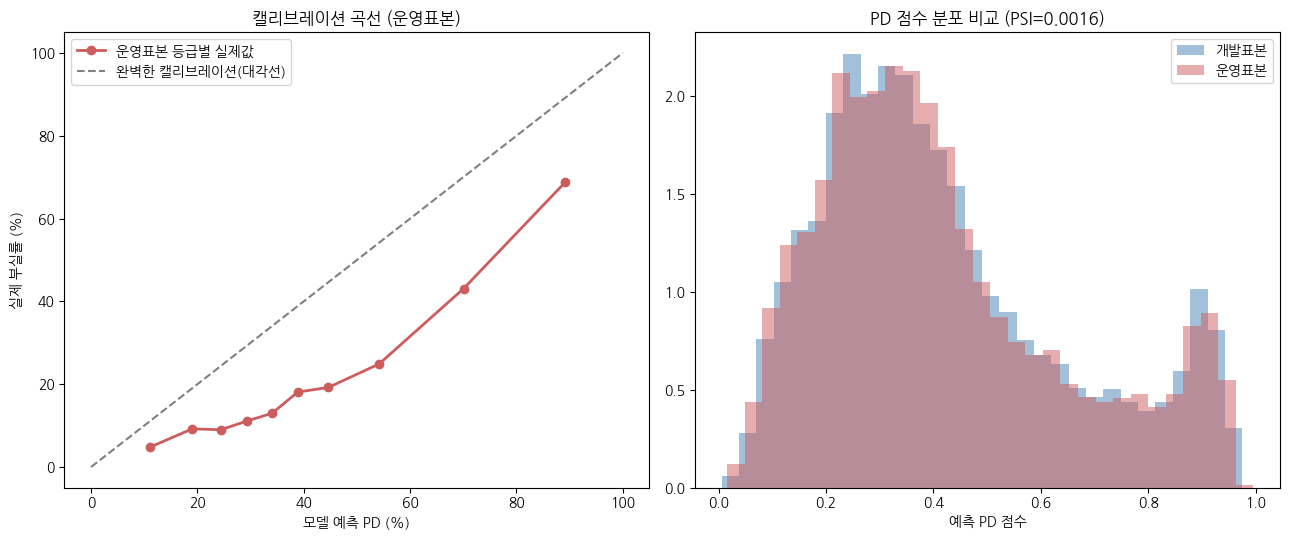

In [3]:
# ============================================================
# [Cell 3] 캘리브레이션 검증 + PSI(Population Stability Index)
# ============================================================

# ------------------------------------------------------------
# 1) 캘리브레이션: 등급별 "예측 PD 평균" vs "실제 부실률" 비교
# ------------------------------------------------------------
# 이미 계산해둔 decile_dev, decile_mon에 평균PD예측과 부실률이 함께 있으므로
# 두 값이 얼마나 가까운지(대각선에 가까운지)로 판단
print("=== 캘리브레이션 비교: 예측 PD vs 실제 부실률 (운영표본 기준) ===")
calib_check = decile_mon[['평균PD예측', '부실률']].copy()
calib_check['차이(%p)'] = (calib_check['부실률'] - calib_check['평균PD예측']) * 100
print(calib_check.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].plot(decile_mon['평균PD예측']*100, decile_mon['부실률']*100,
             marker='o', color='indianred', lw=2, label='운영표본 등급별 실제값')
axes[0].plot([0,100],[0,100], linestyle='--', color='gray', label='완벽한 캘리브레이션(대각선)')
axes[0].set_xlabel('모델 예측 PD (%)')
axes[0].set_ylabel('실제 부실률 (%)')
axes[0].set_title('캘리브레이션 곡선 (운영표본)')
axes[0].legend()

# ------------------------------------------------------------
# 2) PSI 계산: 개발표본 vs 운영표본의 PD 점수 분포 안정성
# ------------------------------------------------------------
def calculate_psi(dev_scores, mon_scores, n_bins=10):
    # 개발표본 기준으로 구간(bin) 경계를 정하고, 운영표본도 같은 경계로 나눔
    bin_edges = np.percentile(dev_scores, np.linspace(0, 100, n_bins + 1))
    bin_edges[0], bin_edges[-1] = -np.inf, np.inf  # 범위 밖 값 포함

    dev_counts, _ = np.histogram(dev_scores, bins=bin_edges)
    mon_counts, _ = np.histogram(mon_scores, bins=bin_edges)

    dev_pct = dev_counts / len(dev_scores)
    mon_pct = mon_counts / len(mon_scores)

    # 0으로 나누기/로그 방지용 최소값 처리
    dev_pct = np.where(dev_pct == 0, 0.0001, dev_pct)
    mon_pct = np.where(mon_pct == 0, 0.0001, mon_pct)

    psi_per_bin = (mon_pct - dev_pct) * np.log(mon_pct / dev_pct)
    return psi_per_bin.sum(), pd.DataFrame({
        '구간': range(1, n_bins+1),
        '개발표본 비중': dev_pct, '운영표본 비중': mon_pct,
        'PSI 기여도': psi_per_bin
    })

psi_total, psi_detail = calculate_psi(dev_df['pd_score'], mon_df['pd_score'])

print(f"\n=== PSI(Population Stability Index) ===")
print(psi_detail.round(4))
print(f"\n전체 PSI: {psi_total:.4f}")
if psi_total < 0.1:
    verdict = "안정적 (변화 없음)"
elif psi_total < 0.25:
    verdict = "주의 (일부 변화 감지)"
else:
    verdict = "불안정 (유의미한 변화, 모델 재개발 검토 필요)"
print(f"판정: {verdict}")
print("(통상 기준: PSI<0.1 안정 / 0.1~0.25 주의 / >0.25 불안정)")

# ------------------------------------------------------------
# 3) 시각화: PD 점수 분포 비교
# ------------------------------------------------------------
axes[1].hist(dev_df['pd_score'], bins=30, alpha=0.5, color='steelblue', label='개발표본', density=True)
axes[1].hist(mon_df['pd_score'], bins=30, alpha=0.5, color='indianred', label='운영표본', density=True)
axes[1].set_title(f'PD 점수 분포 비교 (PSI={psi_total:.4f})')
axes[1].set_xlabel('예측 PD 점수')
axes[1].legend()

plt.tight_layout()
plt.show()

PSI = 0.0016 → 안정적, 예상대로
같은 모집단을 무작위로 나눴으니 분포가 거의 동일한 게 당연. 이 값 자체는 "정상 상황에서 PSI가 실제로 이렇게 낮게 나온다"는 기준점을 확인한 것으로 의미가 있음.

캘리브레이션 곡선 → 심각한 과대예측(Overestimation) 문제 발견
표를 보면 모든 등급에서 "예측 PD"가 "실제 부실률"보다 훨씬 높음. 예를 들어 8등급은 모델이 54.18%를 예측했는데 실제 부실률은 24.89%. 그래프에서도 빨간 선이 대각선 아래로 계속 처져있는 게 뚜렷이 보임.

원인 진단: 이건 모델 변별력(AUC 0.77) 자체의 문제가 아니라, XGBoost 학습 시 넣었던 scale_pos_weight(클래스 불균형 보정) 때문. 이 파라미터는 "부실 고객을 놓치지 말라"고 모델에 가중치를 줘서 순위를 잘 매기게(변별력 향상) 만들지만, 그 대가로 예측 확률값 자체가 실제보다 부풀려지는 부작용이 있음. 즉 **"누가 더 위험한지 순서는 잘 맞히지만, 그 위험도의 절대적인 숫자(%)는 못 믿는다"**는 뜻.

이는 실무에서 자주 발생하는 전형적인 모델리스크 사례 — 변별력 확보를 위한 기법(클래스 재조정)이 캘리브레이션을 훼손하는 트레이드오프. 검증 담당자라면 바로 이런 지점을 잡아내서 "이 모델은 리스크 등급 분류(순위)에는 써도 되지만, 예측 PD 값을 그대로 충당금 산출 등에 쓰면 과잉적립된다"고 지적해야 하는 부분.